# Cross-case flow controls on Voronoï particle heterogeneity



In [36]:
# ============================================================
# 1. IMPORTS AND PROJECT PATHS
# ============================================================

from pathlib import Path
import sys
import json
import importlib
import re
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D


# Notebook location:
# THESIS/z.parcels_postprocessing/notebooks/
NB_DIR = Path.cwd().resolve()
PROJECT_DIR = NB_DIR.parent.parent
PARCELS_DIR = PROJECT_DIR / "z.parcels_postprocessing"
FLOW_DIR = PROJECT_DIR / "z.flow_postprocessing"
FLOW_SCRIPTS_DIR = FLOW_DIR / "scripts"

PARCELS_RESULTS_ROOT = (PARCELS_DIR / "results").resolve()
FLOW_RESULTS_ROOT = (FLOW_DIR / "results").resolve()
FLOW_INPUT_DIR = (FLOW_DIR / "data" / "input").resolve()

for path in [PROJECT_DIR, FLOW_SCRIPTS_DIR, PARCELS_DIR]:
    path = str(path)
    if path not in sys.path:
        sys.path.insert(0, path)

import theme.plot_theme as ptheme
import shcherbina_utils as shu

importlib.reload(ptheme)
ptheme.apply_theme()

importlib.reload(shu)
shu.apply_plot_style()


def apply_cross_case_style():
    """Use the same large-format sizing as the existing cross-case notebooks."""
    shu.apply_plot_style()
    plt.rcParams.update({
        "font.size": max(getattr(ptheme, "FONT_SIZE", 14), 17),
        "axes.titlesize": max(getattr(ptheme, "TITLE_SIZE", 20), 22),
        "axes.labelsize": max(getattr(ptheme, "LABEL_SIZE", 18), 19),
        "xtick.labelsize": max(getattr(ptheme, "TICK_SIZE", 16), 16),
        "ytick.labelsize": max(getattr(ptheme, "TICK_SIZE", 16), 16),
        "legend.fontsize": max(getattr(ptheme, "LEGEND_SIZE", 15), 15),
        "figure.titlesize": max(getattr(ptheme, "SUPTITLE_SIZE", 24), 25),
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "savefig.transparent": False,
    })


apply_cross_case_style()

print(f"Notebook dir       : {NB_DIR}")
print(f"Particle results   : {PARCELS_RESULTS_ROOT}")
print(f"Flow input         : {FLOW_INPUT_DIR}")
print(f"Flow results       : {FLOW_RESULTS_ROOT}")
print(f"Utilities          : {Path(shu.__file__).resolve()}")

Notebook dir       : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\notebooks
Particle results   : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results
Flow input         : C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\data\input
Flow results       : C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results
Utilities          : C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\scripts\shcherbina_utils.py


In [37]:
# ============================================================
# 2. USER SETTINGS
# ============================================================

CASE_NAMES = [
    "run_aug1", "run_aug1_f1", "run_aug1_f2", "run_aug2", "run_aug3",
    "run_dec1", "run_dec2", "run_feb1", "run_jan1", "run_jul1",
    "run_jun1", "run_mar1", "run_may1", "run_nov1", "run_oct1", "run_sep1",
]

PARTICLE_TYPES_TO_PLOT = [
    "Passive particles",
    "GDP drifter",
    "Simple megaplastic",
]

HETEROGENEITY_CACHE_FILENAME = (
    "particle_heterogeneity_2D_vs_3D_selected_snapshots.nc"
)
ACTIVITY_CACHE_FILENAME = "submesoscale_activity_selected_snapshots.nc"

# New name: prevents reuse of the previous selected-snapshot-only cache.
FLOW_CONTROL_CACHE_FILENAME = (
    "particle_flow_controls_lagged_selected_snapshots.nc"
)

REBUILD_FLOW_CONTROL_CACHES = False
USE_EXISTING_ACTIVITY_CACHE = True
USE_EXISTING_DIVERGENCE_JSON = True
SKIP_MISSING_CASES = True

LEVEL_INDICES_3D = (0,)
LEVEL_INDICES_2D = (0,)
DX_3D_FALLBACK = None
DY_3D_FALLBACK = None
DX_2D_FALLBACK = None
DY_2D_FALLBACK = None

# The active-area panel retains the established threshold.
ACTIVE_RO_THRESHOLD = 0.5

# Fixed strong-structure thresholds. These are applied to every case and
# every time and are not estimated from the T=0 distributions.
STRAIN_EXCESS_THRESHOLD = 0.4
VORTICITY_EXCESS_THRESHOLD = 0.4

# Restrict strain excess to strain-dominated points:
# sigma/|f0| > |zeta/f0|.
STRAIN_DOMINATED_ONLY = True

# Flow-output sampling inside each preceding interval.
# 1 uses every available flow output; increase this only to reduce runtime.
INTERVAL_OBS_STRIDE = 1

# T=0 remains available for calculating the first growth interval but is
# excluded from all state scatterplots.
PLOT_DAYS = (3.0, 7.0, 13.0)
SNAPSHOT_MARKERS = {
    3.0: "s",
    7.0: "^",
    13.0: "D",
}

DEFAULT_F0 = 8.0e-5
F0_BY_CASE = {
    "run_aug1_f1": 1.0e-4,
    "run_aug1_f1_2D": 1.0e-4,
    "run_aug1_f2": 6.0e-5,
    "run_aug1_f2_2D": 6.0e-5,
}

# All particle classes are overlaid, so use compact markers.
POINT_SIZE = 44
POINT_ALPHA = 0.82
POINT_EDGE_WIDTH = 0.7

# Trend display for the lag-aware growth figure only:
# "binned_median", "linear", or "none".
GROWTH_TREND_MODE = "binned_median"
TREND_N_BINS = 4
TREND_MIN_POINTS_PER_BIN = 3
TREND_LINE_WIDTH = 2.0

SAVE_FIGURES = True
SAVE_PNG = True
SAVE_PDF = True
SAVE_SUMMARY_CSV = True

OUTPUT_DIR = (
    PARCELS_RESULTS_ROOT
    / "_comparisons"
    / "cross_case_particle_flow_controls_lagged"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SNAPSHOT_SUMMARY_CSV_PATH = (
    OUTPUT_DIR / "particle_heterogeneity_flow_controls_snapshot.csv"
)
INTERVAL_SUMMARY_CSV_PATH = (
    OUTPUT_DIR / "particle_heterogeneity_flow_controls_interval.csv"
)

PARTICLE_COLORS = {
    "Passive particles": shu.get_color("default"),
    "GDP drifter": shu.get_color("secondary"),
    "Simple megaplastic": shu.get_color("highlight"),
}

print(f"Output directory          : {OUTPUT_DIR}")
print(f"Active-Ro threshold       : {ACTIVE_RO_THRESHOLD:g}")
print(f"Strain excess threshold   : {STRAIN_EXCESS_THRESHOLD:g} (fixed)")
print(f"Vorticity excess threshold: {VORTICITY_EXCESS_THRESHOLD:g} (fixed)")
print(f"Strain-dominated only     : {STRAIN_DOMINATED_ONLY}")
print(f"Interval output stride    : {INTERVAL_OBS_STRIDE}")
print(f"Growth trend mode         : {GROWTH_TREND_MODE}")

Output directory          : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\_comparisons\cross_case_particle_flow_controls_lagged
Active-Ro threshold       : 0.5
Strain excess threshold   : 0.4 (fixed)
Vorticity excess threshold: 0.4 (fixed)
Strain-dominated only     : True
Interval output stride    : 1
Growth trend mode         : binned_median


## Flow-control definitions

For normalized strain \(S=\sigma/|f_0|\) and Rossby number
\(Ro=\zeta/f_0\), the strong-structure controls are

\[
M_{\sigma}
=
\left\langle
(S-S_*)_+\,
\mathbf{1}_{S>|Ro|}
\right\rangle,
\]

\[
M_{\zeta^+}
=
\left\langle
(Ro-Ro_*)_+
\right\rangle,
\qquad
M_{\zeta^-}
=
\left\langle
(-Ro-Ro_*)_+
\right\rangle.
\]

Non-exceeding cells contribute zero. Consequently, each metric increases when
strong structures become more extensive, more intense, or both.

For the lag-aware figure, the notebook calculates these metrics at every sampled
flow output within each preceding interval and then uses their interval mean.

In [38]:
# ============================================================
# 3. GENERAL HELPERS
# ============================================================

def text(value):
    return value.decode("utf-8") if isinstance(value, bytes) else str(value)


def slug(value):
    return re.sub(r"[^A-Za-z0-9_-]+", "_", str(value)).strip("_").lower()


def particle_type(label):
    label = " ".join(text(label).lower().split())
    if "passive" in label:
        return "Passive particles"
    if "gdp" in label and "drifter" in label:
        return "GDP drifter"
    if "megaplastic" in label:
        return "Simple megaplastic"
    return None


def dataset_layout(ds):
    time_dim = shu.find_dim(ds["UVEL"].dims, ["T", "time", "iter"])
    z_dim = shu.find_dim(ds["UVEL"].dims, ["Z", "Zmd", "k", "depth"])
    return time_dim, z_dim


def infer_grid_spacing(ds, coordinate_name, fallback=None):
    if coordinate_name in ds.coords:
        coordinate = np.asarray(ds[coordinate_name].values, dtype=float)
        if coordinate.size > 1:
            spacing = float(np.nanmedian(np.abs(np.diff(coordinate))))
            if np.isfinite(spacing) and spacing > 0.0:
                return spacing

    if fallback is not None:
        return float(fallback)

    raise ValueError(
        f"Could not infer grid spacing from coordinate {coordinate_name!r}."
    )


def resolve_f0(case_name, ds=None):
    if case_name in F0_BY_CASE:
        return float(F0_BY_CASE[case_name])

    if ds is not None:
        for key in ("f0_s-1", "f0", "fCori", "coriolis_parameter"):
            if key in ds.attrs:
                value = float(np.asarray(ds.attrs[key]).squeeze())
                if np.isfinite(value) and value != 0.0:
                    return value

    return float(DEFAULT_F0)


def exceedance_statistics(values, threshold, support_mask=None):
    """
    Fixed-threshold area fraction and integrated excess mass.

    Excess mass is the domain mean of max(values-threshold, 0).
    Cells outside support_mask and non-exceeding cells contribute zero.
    """
    values = np.asarray(values, dtype=float)
    finite = np.isfinite(values)

    if support_mask is None:
        support = finite
    else:
        support = finite & np.asarray(support_mask, dtype=bool)

    if not np.any(finite):
        return {
            "area_fraction": np.nan,
            "excess_mass": np.nan,
            "mean_excess_given_active": np.nan,
        }

    active = support & (values > float(threshold))
    excess = np.zeros(values.shape, dtype=float)
    excess[active] = values[active] - float(threshold)

    active_count = int(np.count_nonzero(active))
    finite_count = int(np.count_nonzero(finite))

    return {
        "area_fraction": active_count / finite_count,
        "excess_mass": float(np.sum(excess[finite]) / finite_count),
        "mean_excess_given_active": (
            float(np.mean(excess[active]))
            if active_count > 0
            else 0.0
        ),
    }


def full_domain_active_fraction(ro, threshold=ACTIVE_RO_THRESHOLD):
    """Reuse the helper already used in compare_2D_3D_flow.ipynb."""
    ro = np.asarray(ro, dtype=float)
    ny, nx = ro.shape[-2:]
    full_domain = [{
        "square_id": 1,
        "x0": 0,
        "x1": nx,
        "y0": 0,
        "y1": ny,
    }]
    result = shu.compute_pro_per_square(ro, full_domain, threshold)
    return float(result[0]["PRo"])


def divergence_rms_normalized(div_f):
    div_f = np.asarray(div_f, dtype=float)
    finite = np.isfinite(div_f)
    if not np.any(finite):
        return np.nan
    return float(np.sqrt(np.nanmean(div_f[finite] ** 2)))


def flow_structure_metrics(ro, strain_f, div_f, f0):
    ro = np.asarray(ro, dtype=float)
    strain_f = np.asarray(strain_f, dtype=float)
    div_f = np.asarray(div_f, dtype=float)

    finite_joint = np.isfinite(ro) & np.isfinite(strain_f)
    strain_support = finite_joint.copy()
    if STRAIN_DOMINATED_ONLY:
        strain_support &= strain_f > np.abs(ro)

    strain_stats = exceedance_statistics(
        strain_f,
        threshold=STRAIN_EXCESS_THRESHOLD,
        support_mask=strain_support,
    )
    cyclonic_stats = exceedance_statistics(
        ro,
        threshold=VORTICITY_EXCESS_THRESHOLD,
    )
    anticyclonic_stats = exceedance_statistics(
        -ro,
        threshold=VORTICITY_EXCESS_THRESHOLD,
    )

    div_rms_norm = divergence_rms_normalized(div_f)

    return {
        "active_fraction": full_domain_active_fraction(
            ro,
            threshold=ACTIVE_RO_THRESHOLD,
        ),
        "strain_excess_mass": strain_stats["excess_mass"],
        "strain_exceedance_area_fraction": strain_stats["area_fraction"],
        "strain_mean_excess_given_active": (
            strain_stats["mean_excess_given_active"]
        ),
        "ro_cyclonic_excess_mass": cyclonic_stats["excess_mass"],
        "ro_cyclonic_exceedance_area_fraction": (
            cyclonic_stats["area_fraction"]
        ),
        "ro_cyclonic_mean_excess_given_active": (
            cyclonic_stats["mean_excess_given_active"]
        ),
        "ro_anticyclonic_excess_mass": anticyclonic_stats["excess_mass"],
        "ro_anticyclonic_exceedance_area_fraction": (
            anticyclonic_stats["area_fraction"]
        ),
        "ro_anticyclonic_mean_excess_given_active": (
            anticyclonic_stats["mean_excess_given_active"]
        ),
        "divergence_rms_normalized": div_rms_norm,
        "divergence_rms_s1": abs(float(f0)) * div_rms_norm,
    }


FLOW_METRIC_NAMES = [
    "active_fraction",
    "strain_excess_mass",
    "strain_exceedance_area_fraction",
    "strain_mean_excess_given_active",
    "ro_cyclonic_excess_mass",
    "ro_cyclonic_exceedance_area_fraction",
    "ro_cyclonic_mean_excess_given_active",
    "ro_anticyclonic_excess_mass",
    "ro_anticyclonic_exceedance_area_fraction",
    "ro_anticyclonic_mean_excess_given_active",
    "divergence_rms_normalized",
    "divergence_rms_s1",
]


def mean_metric_records(records):
    return {
        name: float(np.nanmean([record[name] for record in records]))
        for name in FLOW_METRIC_NAMES
    }


def load_characterization(case_name):
    path = (
        FLOW_RESULTS_ROOT
        / case_name
        / f"{case_name}_domain_characterization.json"
    )
    if not path.exists():
        return {}
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def existing_divergence_by_obs(case_name):
    characterization = load_characterization(case_name)
    values = characterization.get(
        "divergence_rms_selected_snapshots_s-1",
        {},
    )
    return {
        int(key): float(value)
        for key, value in values.items()
    }


def load_existing_activity_by_obs(case_name, simulation_label):
    path = (
        FLOW_RESULTS_ROOT
        / case_name
        / "metrics"
        / ACTIVITY_CACHE_FILENAME
    )
    if not path.exists() or not USE_EXISTING_ACTIVITY_CACHE:
        return {}

    with xr.open_dataset(path) as ds_open:
        ds = ds_open.load()

    cached_threshold = float(
        ds.attrs.get("active_ro_threshold", ACTIVE_RO_THRESHOLD)
    )
    if not np.isclose(cached_threshold, ACTIVE_RO_THRESHOLD):
        warnings.warn(
            f"Ignoring {path.name} for {case_name}: threshold "
            f"{cached_threshold:g} differs from {ACTIVE_RO_THRESHOLD:g}."
        )
        return {}

    value_name = (
        "active_fraction_3d"
        if simulation_label == "3D"
        else "active_fraction_2d"
    )
    if "obs_index" not in ds or value_name not in ds:
        return {}

    return {
        int(obs): float(value)
        for obs, value in zip(
            ds["obs_index"].values,
            ds[value_name].values,
        )
    }


def padded_limits(values, fractional_pad=0.07, include_zero=False):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return None

    lo = float(np.nanmin(values))
    hi = float(np.nanmax(values))

    if include_zero:
        lo = min(lo, 0.0)
        hi = max(hi, 0.0)

    if np.isclose(lo, hi):
        scale = max(abs(lo), 1.0)
        return lo - 0.05 * scale, hi + 0.05 * scale

    pad = fractional_pad * (hi - lo)
    return lo - pad, hi + pad


def select_plot_days(data):
    mask = np.zeros(len(data), dtype=bool)
    for day in PLOT_DAYS:
        mask |= np.isclose(data["time_days"].to_numpy(dtype=float), day)
    return data.loc[mask].copy()


def particle_legend_handles():
    return [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            markerfacecolor=PARTICLE_COLORS[group],
            markeredgecolor="white",
            markeredgewidth=0.7,
            markersize=7,
            label=group,
        )
        for group in PARTICLE_TYPES_TO_PLOT
    ]


def snapshot_legend_handles():
    return [
        Line2D(
            [0],
            [0],
            marker=SNAPSHOT_MARKERS[day],
            linestyle="none",
            markerfacecolor="0.55",
            markeredgecolor="white",
            markeredgewidth=0.7,
            markersize=7,
            label=f"T={day:g} d",
        )
        for day in PLOT_DAYS
    ]


def interval_legend_handles():
    intervals = list(zip((0.0,) + PLOT_DAYS[:-1], PLOT_DAYS))
    return [
        Line2D(
            [0],
            [0],
            marker=SNAPSHOT_MARKERS[end_day],
            linestyle="none",
            markerfacecolor="0.55",
            markeredgecolor="white",
            markeredgewidth=0.7,
            markersize=7,
            label=f"{start_day:g}-{end_day:g} d",
        )
        for start_day, end_day in intervals
    ]


def add_inside_legend(ax, interval=False):
    handles = particle_legend_handles()
    handles += (
        interval_legend_handles()
        if interval
        else snapshot_legend_handles()
    )
    ax.legend(
        handles=handles,
        loc="upper right",
        frameon=True,
        framealpha=0.95,
        fontsize=10.5,
        ncol=2,
        borderpad=0.45,
        labelspacing=0.35,
        handletextpad=0.45,
        columnspacing=0.85,
    )


def save_figure(fig, filename_base):
    if not SAVE_FIGURES:
        return

    if SAVE_PNG:
        path = OUTPUT_DIR / f"{filename_base}.png"
        fig.savefig(
            path,
            dpi=getattr(ptheme, "SAVE_DPI", 300),
            bbox_inches="tight",
            facecolor="white",
            transparent=False,
        )
        print(f"Saved: {path}")

    if SAVE_PDF:
        path = OUTPUT_DIR / f"{filename_base}.pdf"
        fig.savefig(
            path,
            bbox_inches="tight",
            facecolor="white",
            transparent=False,
        )
        print(f"Saved: {path}")

In [39]:
# ============================================================
# 4. LOAD THE EXISTING HETEROGENEITY CACHES
# ============================================================

def heterogeneity_cache_path(case_name):
    return (
        FLOW_RESULTS_ROOT
        / case_name
        / "metrics"
        / HETEROGENEITY_CACHE_FILENAME
    )


def load_heterogeneity_case(case_name):
    path = heterogeneity_cache_path(case_name)
    if not path.exists():
        raise FileNotFoundError(path)

    with xr.open_dataset(path) as ds_open:
        ds = ds_open.load()

    return ds


heterogeneity_datasets = {}
skipped_heterogeneity = []

for case_name in CASE_NAMES:
    try:
        ds = load_heterogeneity_case(case_name)
        heterogeneity_datasets[case_name] = ds
        print(
            f"Loaded heterogeneity: {case_name} "
            f"({ds.sizes['particle_class']} classes, "
            f"{ds.sizes['snapshot']} snapshots)"
        )
    except Exception as exc:
        message = f"{case_name}: {type(exc).__name__}: {exc}"
        if not SKIP_MISSING_CASES:
            raise
        skipped_heterogeneity.append(message)
        warnings.warn(message)

if not heterogeneity_datasets:
    raise RuntimeError("No selected-snapshot heterogeneity caches were loaded.")

Loaded heterogeneity: run_aug1 (3 classes, 4 snapshots)
Loaded heterogeneity: run_aug1_f1 (3 classes, 4 snapshots)
Loaded heterogeneity: run_aug1_f2 (3 classes, 4 snapshots)
Loaded heterogeneity: run_aug2 (3 classes, 4 snapshots)
Loaded heterogeneity: run_aug3 (3 classes, 4 snapshots)
Loaded heterogeneity: run_dec1 (3 classes, 4 snapshots)
Loaded heterogeneity: run_dec2 (3 classes, 4 snapshots)
Loaded heterogeneity: run_feb1 (3 classes, 4 snapshots)
Loaded heterogeneity: run_jan1 (3 classes, 4 snapshots)
Loaded heterogeneity: run_jul1 (3 classes, 4 snapshots)
Loaded heterogeneity: run_jun1 (3 classes, 4 snapshots)
Loaded heterogeneity: run_mar1 (3 classes, 4 snapshots)
Loaded heterogeneity: run_may1 (3 classes, 4 snapshots)
Loaded heterogeneity: run_nov1 (3 classes, 4 snapshots)
Loaded heterogeneity: run_oct1 (3 classes, 4 snapshots)
Loaded heterogeneity: run_sep1 (3 classes, 4 snapshots)


## Selected-snapshot and interval-mean flow-control cache

Each case receives a compact cache in

`z.flow_postprocessing/results/<case>/metrics/particle_flow_controls_lagged_selected_snapshots.nc`.

Selected-snapshot diagnostics are retained for the state figure. For the lag-aware
figure, the notebook samples the flow between each pair of selected snapshots,
calculates the same diagnostics at every sampled output, and stores their interval
mean.

In [40]:
# ============================================================
# 5. BUILD OR LOAD FLOW-CONTROL CACHES
# ============================================================

def flow_input_path(case_name):
    return FLOW_INPUT_DIR / f"{case_name}.nc"


def flow_control_cache_path(case_3d):
    return (
        FLOW_RESULTS_ROOT
        / case_3d
        / "metrics"
        / FLOW_CONTROL_CACHE_FILENAME
    )


def cache_matches_selection(ds, obs_3d, obs_2d):
    try:
        conditions = [
            np.array_equal(
                np.asarray(ds["obs_index_3d"].values, dtype=int),
                np.asarray(obs_3d, dtype=int),
            ),
            np.array_equal(
                np.asarray(ds["obs_index_2d"].values, dtype=int),
                np.asarray(obs_2d, dtype=int),
            ),
            np.isclose(
                float(ds.attrs["active_ro_threshold"]),
                float(ACTIVE_RO_THRESHOLD),
            ),
            np.isclose(
                float(ds.attrs["strain_excess_threshold"]),
                float(STRAIN_EXCESS_THRESHOLD),
            ),
            np.isclose(
                float(ds.attrs["vorticity_excess_threshold"]),
                float(VORTICITY_EXCESS_THRESHOLD),
            ),
            bool(int(ds.attrs["strain_dominated_only"]))
            == bool(STRAIN_DOMINATED_ONLY),
            int(ds.attrs["interval_obs_stride"])
            == int(INTERVAL_OBS_STRIDE),
        ]
    except Exception:
        return False

    return bool(all(conditions))


def sampled_interval_indices(start_obs, end_obs):
    start_obs = int(start_obs)
    end_obs = int(end_obs)

    if end_obs <= start_obs:
        raise ValueError(
            f"Interval end {end_obs} must be after start {start_obs}."
        )

    indices = np.arange(
        start_obs,
        end_obs + 1,
        int(INTERVAL_OBS_STRIDE),
        dtype=int,
    )
    if indices[-1] != end_obs:
        indices = np.r_[indices, end_obs]

    return np.unique(indices)


def compute_simulation_controls(
    case_name,
    selected_obs_indices,
    level_indices,
    dx_fallback,
    dy_fallback,
    simulation_label,
    paired_case_3d,
):
    path = flow_input_path(case_name)
    if not path.exists():
        raise FileNotFoundError(path)

    selected_obs_indices = np.asarray(selected_obs_indices, dtype=int)
    cached_activity = load_existing_activity_by_obs(
        paired_case_3d,
        simulation_label,
    )
    cached_divergence = (
        existing_divergence_by_obs(paired_case_3d)
        if simulation_label == "3D" and USE_EXISTING_DIVERGENCE_JSON
        else {}
    )

    with xr.open_dataset(
        path,
        decode_times=False,
        cache=False,
    ) as ds:
        time_dim, z_dim = dataset_layout(ds)
        dx = infer_grid_spacing(ds, "X", fallback=dx_fallback)
        dy = infer_grid_spacing(ds, "Y", fallback=dy_fallback)
        f0 = resolve_f0(case_name, ds=ds)
        n_time = int(ds.sizes[time_dim])

        metric_cache = {}

        def metrics_at_obs(obs_index):
            obs_index = int(obs_index)
            if obs_index in metric_cache:
                return metric_cache[obs_index]

            if obs_index < 0 or obs_index >= n_time:
                raise IndexError(
                    f"{case_name}: observation {obs_index} lies outside "
                    f"0..{n_time - 1}."
                )

            ro, div_f, strain_f = shu.compute_surface_kinematics(
                ds,
                time_dim=time_dim,
                z_dim=z_dim,
                it=obs_index,
                levels=list(level_indices),
                dx=float(dx),
                dy=float(dy),
                f0=float(f0),
            )

            metrics = flow_structure_metrics(
                ro=np.asarray(ro, dtype=float),
                strain_f=np.asarray(strain_f, dtype=float),
                div_f=np.asarray(div_f, dtype=float),
                f0=f0,
            )

            # Reuse exact previously saved values at selected snapshots.
            if obs_index in cached_activity:
                metrics["active_fraction"] = cached_activity[obs_index]

            if obs_index in cached_divergence:
                metrics["divergence_rms_s1"] = cached_divergence[obs_index]
                metrics["divergence_rms_normalized"] = (
                    cached_divergence[obs_index] / abs(float(f0))
                )

            metric_cache[obs_index] = metrics
            return metrics

        selected_records = []
        for obs_index in selected_obs_indices:
            record = dict(metrics_at_obs(obs_index))
            record["obs_index"] = int(obs_index)
            selected_records.append(record)

        interval_records = []
        for interval_index in range(1, selected_obs_indices.size):
            start_obs = int(selected_obs_indices[interval_index - 1])
            end_obs = int(selected_obs_indices[interval_index])
            sample_indices = sampled_interval_indices(start_obs, end_obs)
            sample_records = [
                metrics_at_obs(obs_index)
                for obs_index in sample_indices
            ]

            record = mean_metric_records(sample_records)
            record.update({
                "interval_index": interval_index - 1,
                "start_obs_index": start_obs,
                "end_obs_index": end_obs,
                "n_flow_samples": int(sample_indices.size),
            })
            interval_records.append(record)

    metadata = {
        "f0_s1": float(f0),
        "dx_m": float(dx),
        "dy_m": float(dy),
    }
    return (
        pd.DataFrame(selected_records),
        pd.DataFrame(interval_records),
        metadata,
    )


def build_case_flow_control_cache(case_3d, heterogeneity_ds):
    case_2d = text(
        heterogeneity_ds.attrs.get("case_2d", f"{case_3d}_2D")
    )

    obs_3d = np.asarray(
        heterogeneity_ds["requested_obs_index_3d"].values,
        dtype=int,
    )
    obs_2d = np.asarray(
        heterogeneity_ds["requested_obs_index_2d"].values,
        dtype=int,
    )
    time_3d = np.asarray(
        heterogeneity_ds["target_time_days_3d"].values,
        dtype=float,
    )
    time_2d = np.asarray(
        heterogeneity_ds["target_time_days_2d"].values,
        dtype=float,
    )

    cache_path = flow_control_cache_path(case_3d)
    cache_path.parent.mkdir(parents=True, exist_ok=True)

    if cache_path.exists() and not REBUILD_FLOW_CONTROL_CACHES:
        with xr.open_dataset(cache_path) as ds_open:
            cached = ds_open.load()
        if cache_matches_selection(cached, obs_3d, obs_2d):
            print(f"Loaded flow-control cache: {cache_path}")
            return cached
        warnings.warn(
            f"Rebuilding incompatible flow-control cache: {cache_path}"
        )

    selected_3d, intervals_3d, meta_3d = compute_simulation_controls(
        case_name=case_3d,
        selected_obs_indices=obs_3d,
        level_indices=LEVEL_INDICES_3D,
        dx_fallback=DX_3D_FALLBACK,
        dy_fallback=DY_3D_FALLBACK,
        simulation_label="3D",
        paired_case_3d=case_3d,
    )
    selected_2d, intervals_2d, meta_2d = compute_simulation_controls(
        case_name=case_2d,
        selected_obs_indices=obs_2d,
        level_indices=LEVEL_INDICES_2D,
        dx_fallback=DX_2D_FALLBACK,
        dy_fallback=DY_2D_FALLBACK,
        simulation_label="2D",
        paired_case_3d=case_3d,
    )

    data_vars = {}

    for variable in FLOW_METRIC_NAMES:
        data_vars[f"{variable}_3d"] = (
            "snapshot",
            selected_3d[variable].to_numpy(dtype=float),
        )
        data_vars[f"{variable}_2d"] = (
            "snapshot",
            selected_2d[variable].to_numpy(dtype=float),
        )
        data_vars[f"{variable}_interval_mean_3d"] = (
            "interval",
            intervals_3d[variable].to_numpy(dtype=float),
        )
        data_vars[f"{variable}_interval_mean_2d"] = (
            "interval",
            intervals_2d[variable].to_numpy(dtype=float),
        )

    data_vars.update({
        "n_flow_samples_interval_3d": (
            "interval",
            intervals_3d["n_flow_samples"].to_numpy(dtype=int),
        ),
        "n_flow_samples_interval_2d": (
            "interval",
            intervals_2d["n_flow_samples"].to_numpy(dtype=int),
        ),
    })

    ds = xr.Dataset(
        data_vars=data_vars,
        coords={
            "snapshot": np.arange(obs_3d.size, dtype=int),
            "interval": np.arange(obs_3d.size - 1, dtype=int),
            "obs_index_3d": ("snapshot", obs_3d),
            "obs_index_2d": ("snapshot", obs_2d),
            "time_days_3d": ("snapshot", time_3d),
            "time_days_2d": ("snapshot", time_2d),
            "interval_start_obs_3d": ("interval", obs_3d[:-1]),
            "interval_end_obs_3d": ("interval", obs_3d[1:]),
            "interval_start_obs_2d": ("interval", obs_2d[:-1]),
            "interval_end_obs_2d": ("interval", obs_2d[1:]),
            "interval_start_days": ("interval", time_3d[:-1]),
            "interval_end_days": ("interval", time_3d[1:]),
        },
        attrs={
            "case_3d": case_3d,
            "case_2d": case_2d,
            "active_ro_threshold": float(ACTIVE_RO_THRESHOLD),
            "strain_excess_threshold": float(STRAIN_EXCESS_THRESHOLD),
            "vorticity_excess_threshold": float(
                VORTICITY_EXCESS_THRESHOLD
            ),
            "strain_dominated_only": int(STRAIN_DOMINATED_ONLY),
            "interval_obs_stride": int(INTERVAL_OBS_STRIDE),
            "f0_3d_s1": meta_3d["f0_s1"],
            "f0_2d_s1": meta_2d["f0_s1"],
            "kinematics_function": (
                "shcherbina_utils.compute_surface_kinematics"
            ),
            "interval_definition": (
                "arithmetic mean of each flow metric over all sampled "
                "flow outputs from the interval start through interval end"
            ),
            "description": (
                "Selected-snapshot and preceding-interval flow controls "
                "for cross-case particle-heterogeneity figures."
            ),
        },
    )

    ds.to_netcdf(cache_path)
    print(f"Saved flow-control cache: {cache_path}")
    return ds


flow_control_datasets = {}
skipped_flow = []

for case_name, heterogeneity_ds in heterogeneity_datasets.items():
    try:
        flow_control_datasets[case_name] = build_case_flow_control_cache(
            case_name,
            heterogeneity_ds,
        )
    except Exception as exc:
        message = f"{case_name}: {type(exc).__name__}: {exc}"
        if not SKIP_MISSING_CASES:
            raise
        skipped_flow.append(message)
        warnings.warn(message)

if not flow_control_datasets:
    raise RuntimeError("No flow-control datasets were loaded or built.")

C:\Users\Jelle Gortemaker\AppData\Local\Temp\ipykernel_20448\4167256163.py:335: UserWarning: run_aug1: IndexError: run_aug1: observation 24 lies outside 0..0.
  warnings.warn(message)


Saved flow-control cache: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_aug1_f1\metrics\particle_flow_controls_lagged_selected_snapshots.nc
Saved flow-control cache: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_aug1_f2\metrics\particle_flow_controls_lagged_selected_snapshots.nc
Saved flow-control cache: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_aug2\metrics\particle_flow_controls_lagged_selected_snapshots.nc
Saved flow-control cache: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_aug3\metrics\particle_flow_controls_lagged_selected_snapshots.nc
Saved flow-control cache: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_dec1\metrics\particle_flow_controls_lagged_selected_snapshots.nc
Saved flow-control cache: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_dec2\metrics\particle_flow_controls_lagged_selected

In [41]:
# ============================================================
# 6. ASSEMBLE SNAPSHOT AND INTERVAL TABLES
# ============================================================

def resolve_particle_group(heterogeneity_ds, particle_index):
    labels = [
        text(heterogeneity_ds[name].values[particle_index])
        for name in (
            "particle_panel_label",
            "source_particle_label_3d",
            "source_particle_label_2d",
            "particle_key",
        )
        if name in heterogeneity_ds
    ]
    label = next(
        (value for value in labels if value),
        f"particle_{particle_index}",
    )
    return label, particle_type(label)


snapshot_records = []
interval_records = []

for case_name, flow_ds in flow_control_datasets.items():
    heterogeneity_ds = heterogeneity_datasets[case_name]

    for particle_index in range(
        heterogeneity_ds.sizes["particle_class"]
    ):
        label, group = resolve_particle_group(
            heterogeneity_ds,
            particle_index,
        )
        if group is None:
            continue

        h3 = np.asarray(
            heterogeneity_ds["heterogeneity_3d"].values[particle_index],
            dtype=float,
        )
        h2 = np.asarray(
            heterogeneity_ds["heterogeneity_2d"].values[particle_index],
            dtype=float,
        )
        days = np.asarray(
            heterogeneity_ds["target_time_days_3d"].values,
            dtype=float,
        )

        for snapshot_index, day in enumerate(days):
            row = {
                "case_3d": case_name,
                "case_2d": text(
                    heterogeneity_ds.attrs.get(
                        "case_2d",
                        f"{case_name}_2D",
                    )
                ),
                "particle_type": group,
                "particle_label": label,
                "snapshot": snapshot_index,
                "time_days": float(day),
                "heterogeneity_3d": float(h3[snapshot_index]),
                "heterogeneity_2d": float(h2[snapshot_index]),
            }

            for variable in FLOW_METRIC_NAMES:
                row[f"{variable}_3d"] = float(
                    flow_ds[f"{variable}_3d"].values[snapshot_index]
                )
                row[f"{variable}_2d"] = float(
                    flow_ds[f"{variable}_2d"].values[snapshot_index]
                )

            row["heterogeneity_bias_2d_minus_3d"] = (
                row["heterogeneity_2d"] - row["heterogeneity_3d"]
            )
            snapshot_records.append(row)

        for interval_index in range(days.size - 1):
            start_day = float(days[interval_index])
            end_day = float(days[interval_index + 1])
            duration_days = end_day - start_day

            if duration_days <= 0:
                raise ValueError(
                    f"{case_name}: non-positive interval duration."
                )

            delta_h3 = float(h3[interval_index + 1] - h3[interval_index])
            delta_h2 = float(h2[interval_index + 1] - h2[interval_index])

            row = {
                "case_3d": case_name,
                "particle_type": group,
                "particle_label": label,
                "interval": interval_index,
                "interval_start_days": start_day,
                "interval_end_days": end_day,
                "interval_duration_days": duration_days,
                "heterogeneity_change_3d": delta_h3,
                "heterogeneity_change_2d": delta_h2,
                "heterogeneity_growth_rate_3d_per_day": (
                    delta_h3 / duration_days
                ),
                "heterogeneity_growth_rate_2d_per_day": (
                    delta_h2 / duration_days
                ),
            }

            for variable in FLOW_METRIC_NAMES:
                row[f"{variable}_interval_mean_3d"] = float(
                    flow_ds[
                        f"{variable}_interval_mean_3d"
                    ].values[interval_index]
                )
                row[f"{variable}_interval_mean_2d"] = float(
                    flow_ds[
                        f"{variable}_interval_mean_2d"
                    ].values[interval_index]
                )

            interval_records.append(row)


snapshot_df = pd.DataFrame(snapshot_records)
interval_df = pd.DataFrame(interval_records)

if snapshot_df.empty or interval_df.empty:
    raise RuntimeError("The assembled snapshot or interval table is empty.")

snapshot_df["time_days"] = snapshot_df["time_days"].round(8)
state_plot_df = select_plot_days(snapshot_df)

snapshot_df = snapshot_df.sort_values(
    ["particle_type", "case_3d", "time_days"]
).reset_index(drop=True)
interval_df = interval_df.sort_values(
    ["particle_type", "case_3d", "interval_end_days"]
).reset_index(drop=True)

display(state_plot_df)
display(interval_df)

if SAVE_SUMMARY_CSV:
    snapshot_df.to_csv(SNAPSHOT_SUMMARY_CSV_PATH, index=False)
    interval_df.to_csv(INTERVAL_SUMMARY_CSV_PATH, index=False)
    print(f"Saved: {SNAPSHOT_SUMMARY_CSV_PATH}")
    print(f"Saved: {INTERVAL_SUMMARY_CSV_PATH}")

,case_3d,case_2d,particle_type,particle_label,snapshot,time_days,heterogeneity_3d,heterogeneity_2d,active_fraction_3d,active_fraction_2d,...,ro_anticyclonic_excess_mass_2d,ro_anticyclonic_exceedance_area_fraction_3d,ro_anticyclonic_exceedance_area_fraction_2d,ro_anticyclonic_mean_excess_given_active_3d,ro_anticyclonic_mean_excess_given_active_2d,divergence_rms_normalized_3d,divergence_rms_normalized_2d,divergence_rms_s1_3d,divergence_rms_s1_2d,heterogeneity_bias_2d_minus_3d
1,run_aug1_f1,run_aug1_f1_2D,Passive particles,Passive particles,1,3.0,1.104990,1.013052,0.017590,0.012806,...,0.000141,0.000805,0.002392,0.059652,0.058925,0.039150,0.006323,0.000004,6.323493e-07,-0.091938
2,run_aug1_f1,run_aug1_f1_2D,Passive particles,Passive particles,2,7.0,1.346820,1.031882,0.018341,0.008068,...,0.000095,0.000816,0.001881,0.071541,0.050562,0.036365,0.005978,0.000004,5.977804e-07,-0.314937
3,run_aug1_f1,run_aug1_f1_2D,Passive particles,Passive particles,3,13.0,1.678077,1.020755,0.013412,0.005348,...,0.000050,0.000092,0.001041,0.050016,0.048043,0.037564,0.005477,0.000004,5.477482e-07,-0.657322
5,run_aug1_f1,run_aug1_f1_2D,GDP drifter,"Simple GDP drifter, St=6.438e-03",1,3.0,1.125255,1.018926,0.017590,0.012806,...,0.000141,0.000805,0.002392,0.059652,0.058925,0.039150,0.006323,0.000004,6.323493e-07,-0.106329
6,run_aug1_f1,run_aug1_f1_2D,GDP drifter,"Simple GDP drifter, St=6.438e-03",2,7.0,1.395064,1.051572,0.018341,0.008068,...,0.000095,0.000816,0.001881,0.071541,0.050562,0.036365,0.005978,0.000004,5.977804e-07,-0.343491
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174,run_sep1,run_sep1_2D,GDP drifter,"Simple GDP drifter, St=4.079e-03",2,7.0,1.345186,1.051799,0.004719,0.002335,...,0.000061,0.000000,0.000809,0.000000,0.075326,0.072726,0.007193,0.000006,5.754376e-07,-0.293386
175,run_sep1,run_sep1_2D,GDP drifter,"Simple GDP drifter, St=4.079e-03",3,13.0,1.712763,1.061726,0.004402,0.001568,...,0.000004,0.000000,0.000149,0.000000,0.023911,0.079466,0.005067,0.000006,4.053248e-07,-0.651037
177,run_sep1,run_sep1_2D,Simple megaplastic,"Simple megaplastic, St=4.615e-02",1,3.0,1.125217,1.041820,0.005863,0.004108,...,0.000069,0.000000,0.001007,0.000000,0.068416,0.073536,0.011047,0.000006,8.837266e-07,-0.083396
178,run_sep1,run_sep1_2D,Simple megaplastic,"Simple megaplastic, St=4.615e-02",2,7.0,1.377894,1.059017,0.004719,0.002335,...,0.000061,0.000000,0.000809,0.000000,0.075326,0.072726,0.007193,0.000006,5.754376e-07,-0.318877


,case_3d,particle_type,particle_label,interval,interval_start_days,interval_end_days,interval_duration_days,heterogeneity_change_3d,heterogeneity_change_2d,heterogeneity_growth_rate_3d_per_day,...,ro_anticyclonic_excess_mass_interval_mean_3d,ro_anticyclonic_excess_mass_interval_mean_2d,ro_anticyclonic_exceedance_area_fraction_interval_mean_3d,ro_anticyclonic_exceedance_area_fraction_interval_mean_2d,ro_anticyclonic_mean_excess_given_active_interval_mean_3d,ro_anticyclonic_mean_excess_given_active_interval_mean_2d,divergence_rms_normalized_interval_mean_3d,divergence_rms_normalized_interval_mean_2d,divergence_rms_s1_interval_mean_3d,divergence_rms_s1_interval_mean_2d
0,run_aug1_f1,GDP drifter,"Simple GDP drifter, St=6.438e-03",0,0.0,3.0,3.0,0.093972,-0.012303,0.031324,...,5.557681e-05,0.000120,0.000813,0.001551,0.069013,0.079903,0.037372,0.009496,0.000004,9.496418e-07
1,run_aug1_f1,GDP drifter,"Simple GDP drifter, St=6.438e-03",1,3.0,7.0,4.0,0.269809,0.032646,0.067452,...,7.979491e-05,0.000140,0.001017,0.002568,0.078112,0.054065,0.037679,0.005974,0.000004,5.973673e-07
2,run_aug1_f1,GDP drifter,"Simple GDP drifter, St=6.438e-03",2,7.0,13.0,6.0,0.368768,0.005736,0.061461,...,2.947155e-05,0.000066,0.000590,0.001238,0.051356,0.053055,0.035721,0.005897,0.000004,5.897358e-07
3,run_aug1_f2,GDP drifter,"Simple GDP drifter, St=4.070e-03",0,0.0,3.0,3.0,0.146557,-0.015823,0.048852,...,2.439933e-05,0.000063,0.000723,0.001592,0.045060,0.038945,0.067195,0.012413,0.000004,7.447707e-07
4,run_aug1_f2,GDP drifter,"Simple GDP drifter, St=4.070e-03",1,3.0,7.0,4.0,0.293656,-0.007026,0.073414,...,6.293153e-06,0.000186,0.000148,0.002966,0.039649,0.057425,0.061524,0.006357,0.000004,3.814337e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130,run_oct1,Simple megaplastic,"Simple megaplastic, St=2.894e-02",1,3.0,7.0,4.0,0.128664,0.022779,0.032166,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.047825,0.002629,0.000004,2.103046e-07
131,run_oct1,Simple megaplastic,"Simple megaplastic, St=2.894e-02",2,7.0,13.0,6.0,0.233525,0.032405,0.038921,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.046310,0.001678,0.000004,1.342107e-07
132,run_sep1,Simple megaplastic,"Simple megaplastic, St=4.615e-02",0,0.0,3.0,3.0,0.093798,0.010556,0.031266,...,4.243878e-07,0.000033,0.000015,0.000543,0.011596,0.050295,0.072190,0.019854,0.000006,1.588335e-06
133,run_sep1,Simple megaplastic,"Simple megaplastic, St=4.615e-02",1,3.0,7.0,4.0,0.252677,0.017197,0.063169,...,1.489336e-06,0.000075,0.000088,0.000988,0.006066,0.076046,0.074749,0.008261,0.000006,6.608514e-07


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\_comparisons\cross_case_particle_flow_controls_lagged\particle_heterogeneity_flow_controls_snapshot.csv
Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\_comparisons\cross_case_particle_flow_controls_lagged\particle_heterogeneity_flow_controls_interval.csv


In [42]:
# ============================================================
# 7. PLOTTING HELPERS
# ============================================================

STATE_ROWS = [
    {
        "key_3d": "active_fraction_3d",
        "key_2d": "active_fraction_2d",
        "label": r"$P(|\zeta/f_0|>0.5)$",
    },
    {
        "key_3d": "strain_excess_mass_3d",
        "key_2d": "strain_excess_mass_2d",
        "label": (
            rf"Strong-strain excess mass "
            rf"$M_{{\sigma,\mathrm{{SD}}}}(S_*={STRAIN_EXCESS_THRESHOLD:g})$"
            if STRAIN_DOMINATED_ONLY
            else
            rf"Strong-strain excess mass "
            rf"$M_\sigma(S_*={STRAIN_EXCESS_THRESHOLD:g})$"
        ),
    },
    {
        "key_3d": "ro_cyclonic_excess_mass_3d",
        "key_2d": "ro_cyclonic_excess_mass_2d",
        "label": (
            rf"Cyclonic excess mass "
            rf"$M_{{\zeta^+}}(Ro_*={VORTICITY_EXCESS_THRESHOLD:g})$"
        ),
    },
    {
        "key_3d": "ro_anticyclonic_excess_mass_3d",
        "key_2d": "ro_anticyclonic_excess_mass_2d",
        "label": (
            rf"Anticyclonic excess mass "
            rf"$M_{{\zeta^-}}(Ro_*={VORTICITY_EXCESS_THRESHOLD:g})$"
        ),
    },
    {
        "key_3d": "divergence_rms_s1_3d",
        "key_2d": None,
        "label": r"3D RMS divergence [s$^{-1}$]",
    },
]


INTERVAL_ROWS = [
    {
        "key_3d": "active_fraction_interval_mean_3d",
        "key_2d": "active_fraction_interval_mean_2d",
        "label": r"Interval mean $P(|\zeta/f_0|>0.5)$",
    },
    {
        "key_3d": "strain_excess_mass_interval_mean_3d",
        "key_2d": "strain_excess_mass_interval_mean_2d",
        "label": r"Interval mean strong-strain excess mass",
    },
    {
        "key_3d": "ro_cyclonic_excess_mass_interval_mean_3d",
        "key_2d": "ro_cyclonic_excess_mass_interval_mean_2d",
        "label": r"Interval mean cyclonic excess mass",
    },
    {
        "key_3d": "ro_anticyclonic_excess_mass_interval_mean_3d",
        "key_2d": "ro_anticyclonic_excess_mass_interval_mean_2d",
        "label": r"Interval mean anticyclonic excess mass",
    },
    {
        "key_3d": "divergence_rms_s1_interval_mean_3d",
        "key_2d": None,
        "label": r"Interval mean 3D RMS divergence [s$^{-1}$]",
    },
]


def format_panel(ax, xlabel, ylabel=None):
    ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.grid(
        True,
        which="major",
        alpha=getattr(ptheme, "GRID_ALPHA", 0.35),
    )
    ax.set_facecolor("white")


def scatter_state(ax, data, x_key, y_key):
    for group in PARTICLE_TYPES_TO_PLOT:
        group_data = data[data["particle_type"] == group]
        for day in PLOT_DAYS:
            subset = group_data[
                np.isclose(group_data["time_days"], day)
            ]
            ax.scatter(
                subset[x_key],
                subset[y_key],
                marker=SNAPSHOT_MARKERS[day],
                s=POINT_SIZE,
                color=PARTICLE_COLORS[group],
                edgecolors="white",
                linewidths=POINT_EDGE_WIDTH,
                alpha=POINT_ALPHA,
                zorder=3,
            )


def scatter_interval(ax, data, x_key, y_key):
    for group in PARTICLE_TYPES_TO_PLOT:
        group_data = data[data["particle_type"] == group]
        for end_day in PLOT_DAYS:
            subset = group_data[
                np.isclose(group_data["interval_end_days"], end_day)
            ]
            ax.scatter(
                subset[x_key],
                subset[y_key],
                marker=SNAPSHOT_MARKERS[end_day],
                s=POINT_SIZE,
                color=PARTICLE_COLORS[group],
                edgecolors="white",
                linewidths=POINT_EDGE_WIDTH,
                alpha=POINT_ALPHA,
                zorder=3,
            )


def add_growth_trend(ax, data, x_key, y_key):
    if GROWTH_TREND_MODE == "none":
        return

    for group in PARTICLE_TYPES_TO_PLOT:
        subset = data[data["particle_type"] == group][
            [x_key, y_key]
        ].dropna()
        if len(subset) < max(3, TREND_MIN_POINTS_PER_BIN):
            continue

        x = subset[x_key].to_numpy(dtype=float)
        y = subset[y_key].to_numpy(dtype=float)
        color = PARTICLE_COLORS[group]

        if GROWTH_TREND_MODE == "linear":
            if np.unique(x).size < 2:
                continue
            slope, intercept = np.polyfit(x, y, 1)
            x_line = np.linspace(np.nanmin(x), np.nanmax(x), 100)
            ax.plot(
                x_line,
                slope * x_line + intercept,
                color=color,
                linewidth=TREND_LINE_WIDTH,
                alpha=0.9,
                zorder=4,
            )
            continue

        if GROWTH_TREND_MODE != "binned_median":
            raise ValueError(
                "GROWTH_TREND_MODE must be 'binned_median', "
                "'linear', or 'none'."
            )

        n_unique = np.unique(x).size
        n_bins = min(int(TREND_N_BINS), n_unique)
        if n_bins < 2:
            continue

        trend_data = subset.copy()
        try:
            trend_data["bin"] = pd.qcut(
                trend_data[x_key],
                q=n_bins,
                duplicates="drop",
            )
        except ValueError:
            continue

        binned = (
            trend_data.groupby("bin", observed=True)
            .agg(
                x_median=(x_key, "median"),
                y_median=(y_key, "median"),
                count=(y_key, "size"),
            )
            .reset_index(drop=True)
        )
        binned = binned[
            binned["count"] >= TREND_MIN_POINTS_PER_BIN
        ].sort_values("x_median")

        if len(binned) < 2:
            continue

        ax.plot(
            binned["x_median"],
            binned["y_median"],
            color=color,
            linewidth=TREND_LINE_WIDTH,
            marker="o",
            markersize=4.5,
            alpha=0.95,
            zorder=4,
        )

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\_comparisons\cross_case_particle_flow_controls_lagged\particle_heterogeneity_flow_controls_state_all_classes.png
Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\_comparisons\cross_case_particle_flow_controls_lagged\particle_heterogeneity_flow_controls_state_all_classes.pdf


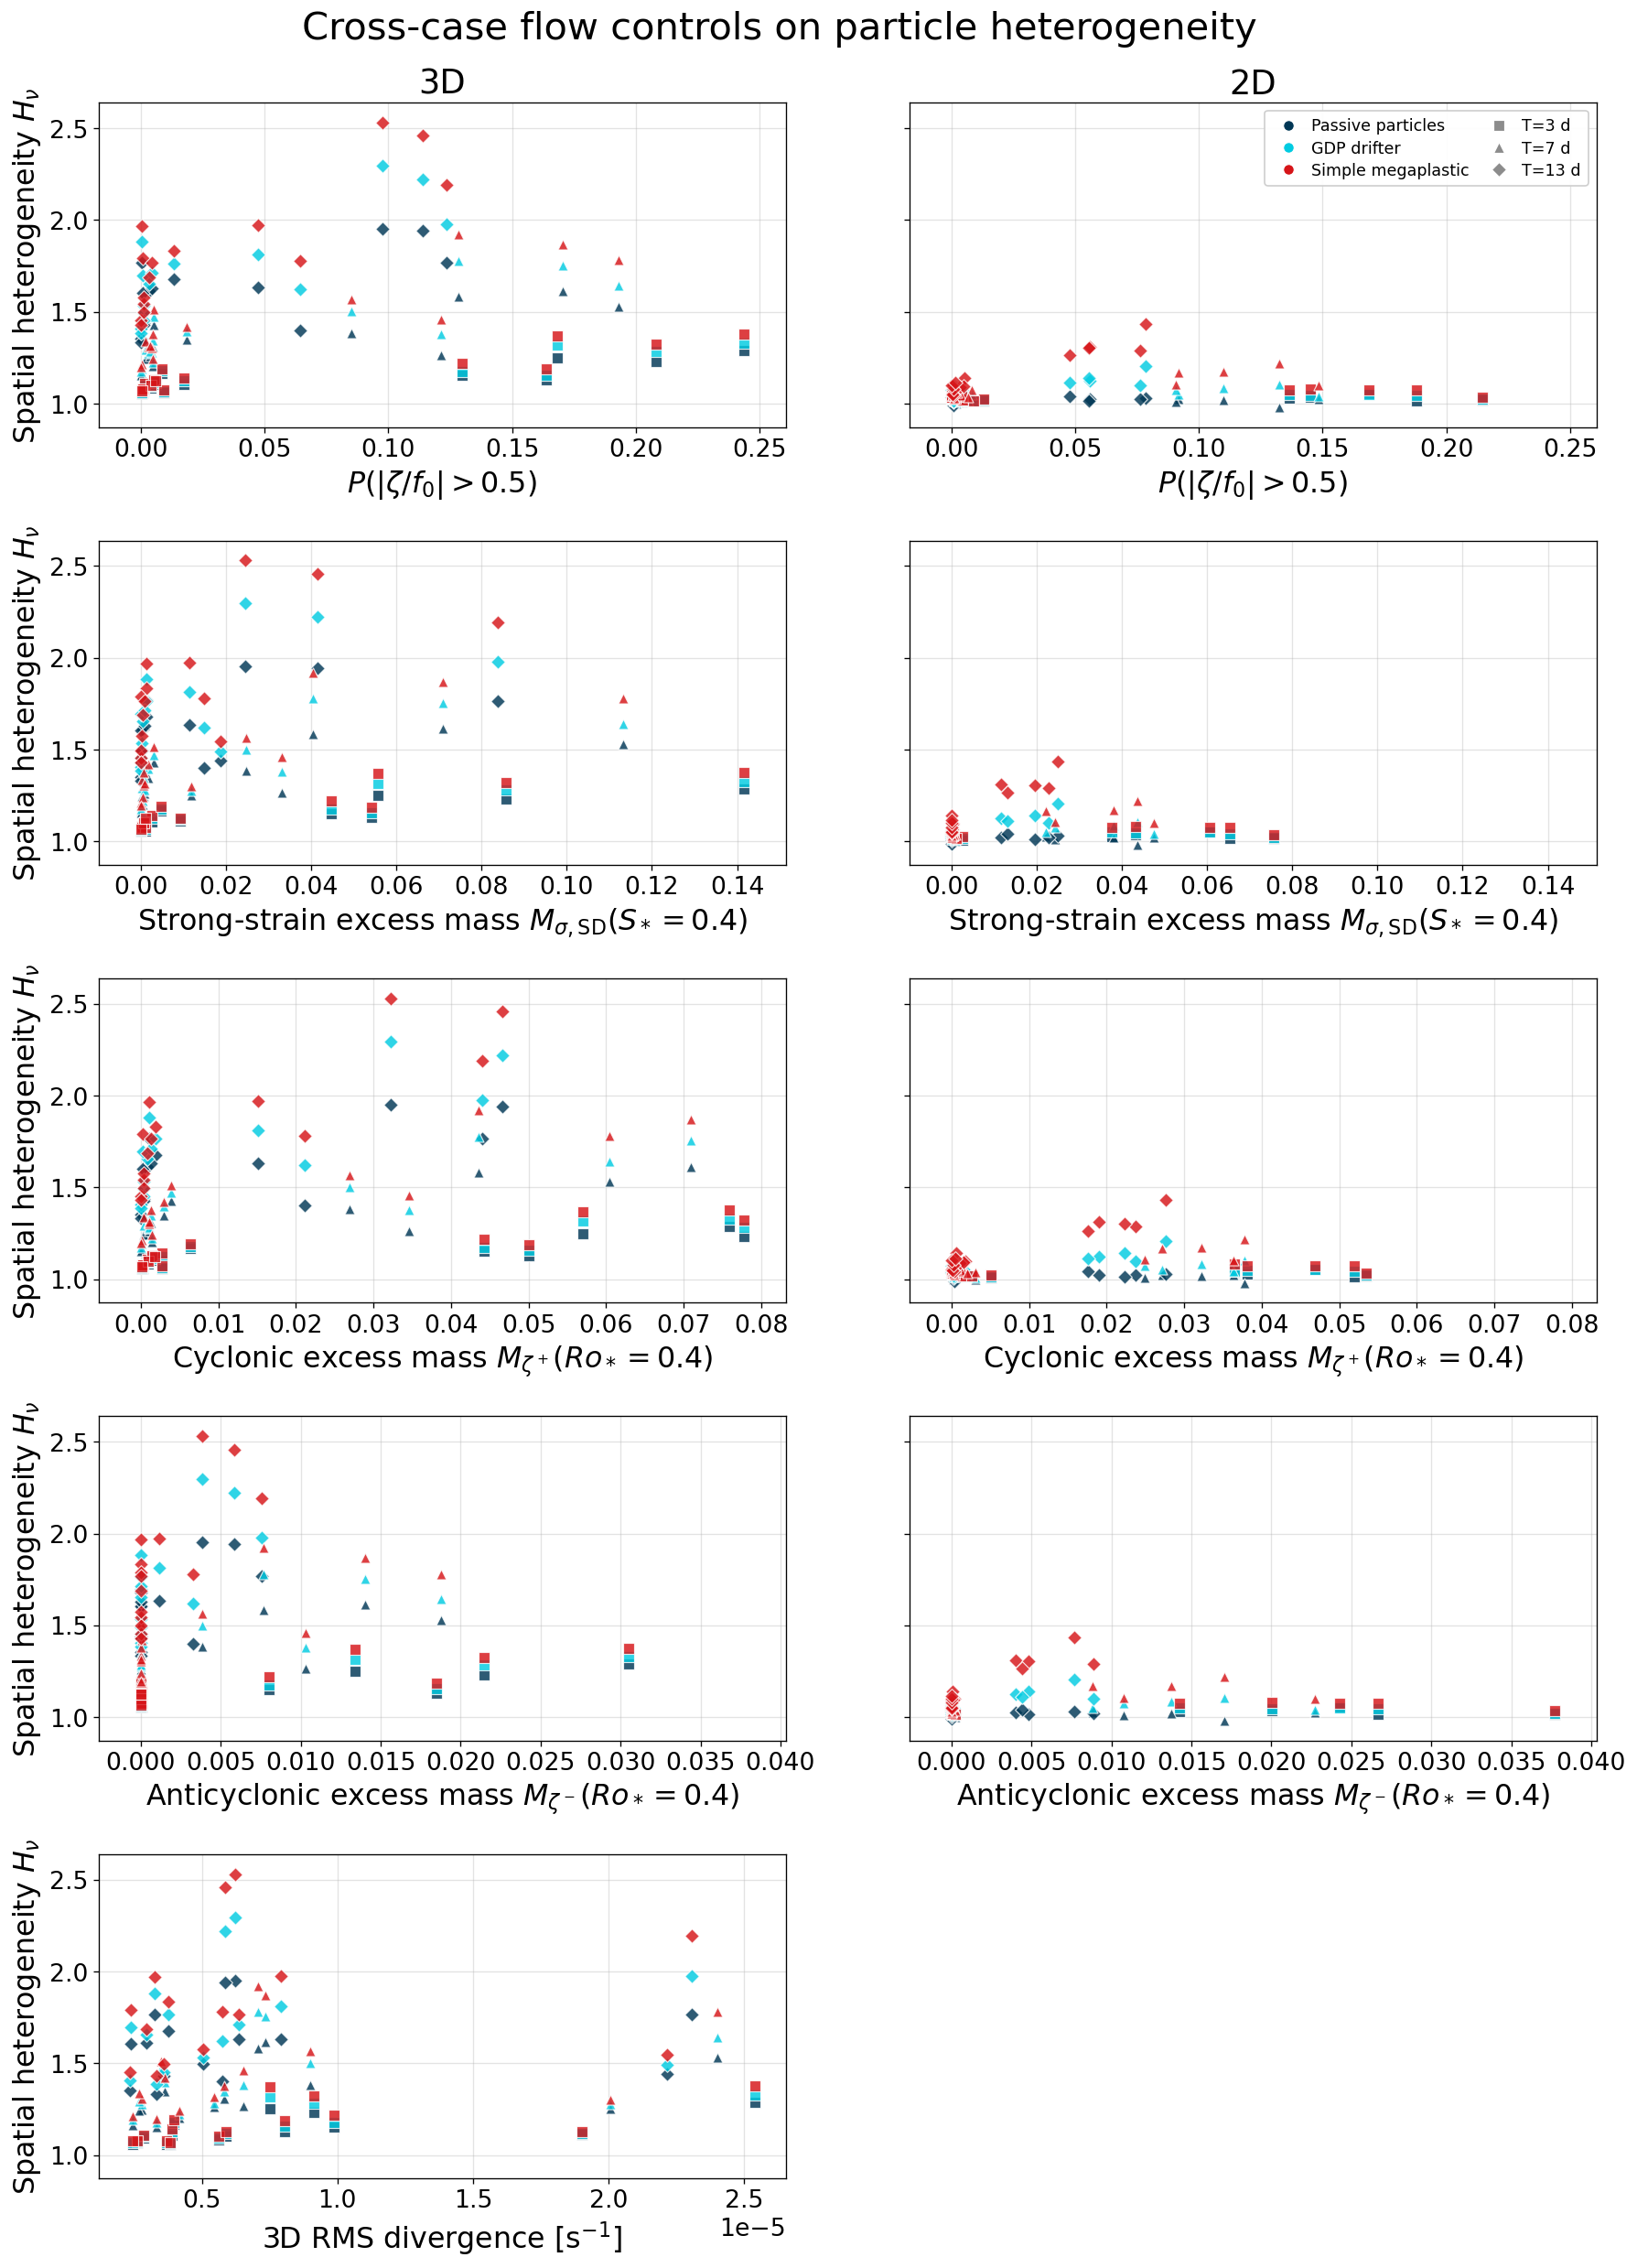

In [43]:
# ============================================================
# 8. STATE FIGURE: H_nu VERSUS SAME-SNAPSHOT FLOW CONTROLS
# ============================================================

apply_cross_case_style()
data = state_plot_df.copy()

fig, axes = plt.subplots(
    nrows=5,
    ncols=2,
    figsize=(15.5, 21.0),
    sharey=True,
    facecolor="white",
    constrained_layout=False,
)

y_limits = padded_limits(
    np.r_[
        data["heterogeneity_3d"].to_numpy(dtype=float),
        data["heterogeneity_2d"].to_numpy(dtype=float),
    ]
)

axes[0, 0].set_title("3D")
axes[0, 1].set_title("2D")

for row_index, spec in enumerate(STATE_ROWS):
    ax_3d = axes[row_index, 0]
    scatter_state(
        ax_3d,
        data,
        spec["key_3d"],
        "heterogeneity_3d",
    )
    format_panel(
        ax_3d,
        spec["label"],
        r"Spatial heterogeneity $H_\nu$",
    )
    if y_limits is not None:
        ax_3d.set_ylim(*y_limits)

    if spec["key_2d"] is None:
        axes[row_index, 1].axis("off")
        continue

    ax_2d = axes[row_index, 1]
    scatter_state(
        ax_2d,
        data,
        spec["key_2d"],
        "heterogeneity_2d",
    )
    format_panel(ax_2d, spec["label"])
    if y_limits is not None:
        ax_2d.set_ylim(*y_limits)

    row_limits = padded_limits(
        np.r_[
            data[spec["key_3d"]].to_numpy(dtype=float),
            data[spec["key_2d"]].to_numpy(dtype=float),
        ],
        include_zero=True,
    )
    if row_limits is not None:
        ax_3d.set_xlim(*row_limits)
        ax_2d.set_xlim(*row_limits)

axes[4, 0].ticklabel_format(
    axis="x",
    style="sci",
    scilimits=(0, 0),
)

# One combined, title-free legend inside the first 2D panel.
add_inside_legend(axes[0, 1], interval=False)

fig.suptitle(
    "Cross-case flow controls on particle heterogeneity",
    y=0.995,
)
fig.subplots_adjust(
    left=0.10,
    right=0.98,
    bottom=0.055,
    top=0.955,
    hspace=0.35,
    wspace=0.18,
)

save_figure(
    fig,
    "particle_heterogeneity_flow_controls_state_all_classes",
)
plt.show()

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\_comparisons\cross_case_particle_flow_controls_lagged\particle_heterogeneity_growth_preceding_flow_all_classes.png
Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\_comparisons\cross_case_particle_flow_controls_lagged\particle_heterogeneity_growth_preceding_flow_all_classes.pdf


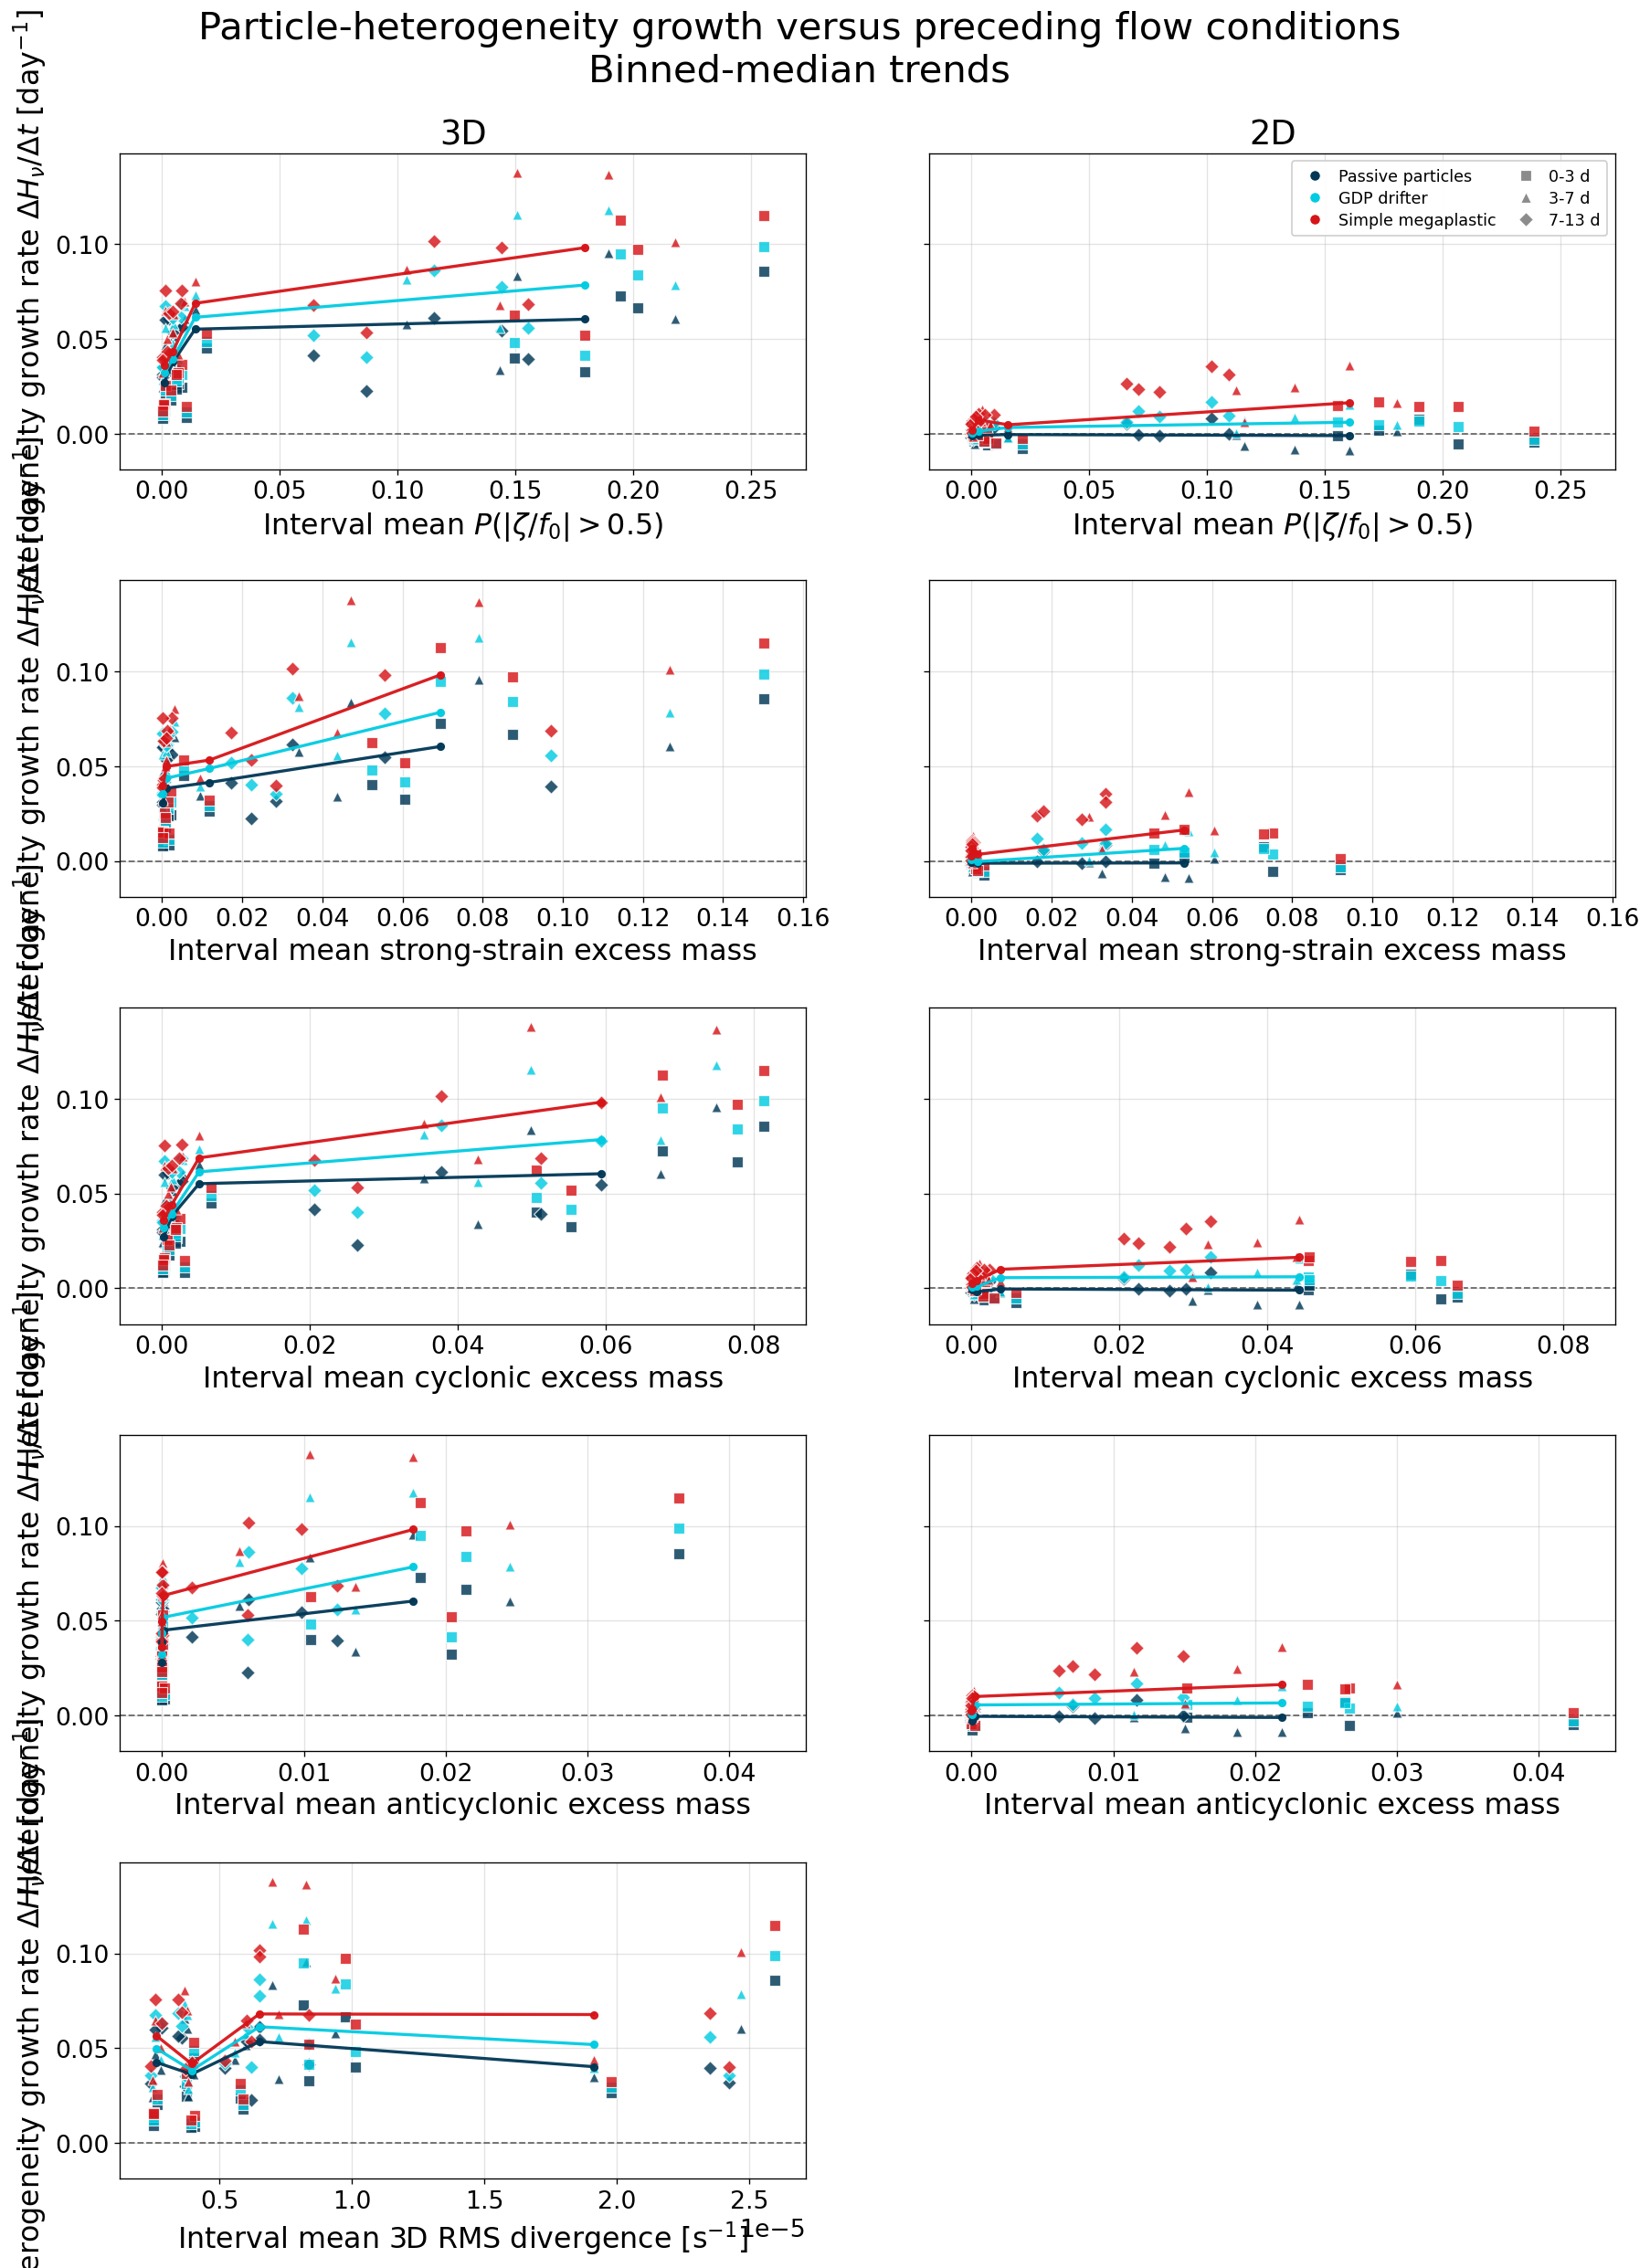

In [44]:
# ============================================================
# 9. LAG-AWARE FIGURE:
#    HETEROGENEITY GROWTH RATE VERSUS PRECEDING-INTERVAL FLOW
# ============================================================

apply_cross_case_style()
data = interval_df.copy()

fig, axes = plt.subplots(
    nrows=5,
    ncols=2,
    figsize=(15.5, 21.0),
    sharey=True,
    facecolor="white",
    constrained_layout=False,
)

y3 = "heterogeneity_growth_rate_3d_per_day"
y2 = "heterogeneity_growth_rate_2d_per_day"

y_limits = padded_limits(
    np.r_[
        data[y3].to_numpy(dtype=float),
        data[y2].to_numpy(dtype=float),
    ],
    include_zero=True,
)

axes[0, 0].set_title("3D")
axes[0, 1].set_title("2D")

for row_index, spec in enumerate(INTERVAL_ROWS):
    ax_3d = axes[row_index, 0]
    scatter_interval(ax_3d, data, spec["key_3d"], y3)
    add_growth_trend(ax_3d, data, spec["key_3d"], y3)
    ax_3d.axhline(
        0.0,
        color=shu.get_color("reference"),
        linestyle="--",
        linewidth=1.1,
        alpha=0.75,
    )
    format_panel(
        ax_3d,
        spec["label"],
        r"Heterogeneity growth rate "
        r"$\Delta H_\nu/\Delta t$ [day$^{-1}$]",
    )
    if y_limits is not None:
        ax_3d.set_ylim(*y_limits)

    if spec["key_2d"] is None:
        axes[row_index, 1].axis("off")
        continue

    ax_2d = axes[row_index, 1]
    scatter_interval(ax_2d, data, spec["key_2d"], y2)
    add_growth_trend(ax_2d, data, spec["key_2d"], y2)
    ax_2d.axhline(
        0.0,
        color=shu.get_color("reference"),
        linestyle="--",
        linewidth=1.1,
        alpha=0.75,
    )
    format_panel(ax_2d, spec["label"])
    if y_limits is not None:
        ax_2d.set_ylim(*y_limits)

    row_limits = padded_limits(
        np.r_[
            data[spec["key_3d"]].to_numpy(dtype=float),
            data[spec["key_2d"]].to_numpy(dtype=float),
        ],
        include_zero=True,
    )
    if row_limits is not None:
        ax_3d.set_xlim(*row_limits)
        ax_2d.set_xlim(*row_limits)

axes[4, 0].ticklabel_format(
    axis="x",
    style="sci",
    scilimits=(0, 0),
)

add_inside_legend(axes[0, 1], interval=True)

trend_label = {
    "binned_median": "Binned-median trends",
    "linear": "Linear trends",
    "none": "No trend overlay",
}[GROWTH_TREND_MODE]

fig.suptitle(
    "Particle-heterogeneity growth versus preceding flow conditions"
    f"\n{trend_label}",
    y=0.997,
)
fig.subplots_adjust(
    left=0.10,
    right=0.98,
    bottom=0.055,
    top=0.935,
    hspace=0.35,
    wspace=0.18,
)

save_figure(
    fig,
    "particle_heterogeneity_growth_preceding_flow_all_classes",
)
plt.show()

In [45]:
# ============================================================
# 10. OUTPUT CHECK
# ============================================================

print(f"Snapshot table : {SNAPSHOT_SUMMARY_CSV_PATH}")
print(f"Interval table : {INTERVAL_SUMMARY_CSV_PATH}")
print(f"Figure directory: {OUTPUT_DIR}")

for path in sorted(OUTPUT_DIR.glob("*")):
    print(path.name)

if skipped_heterogeneity:
    print("\nSkipped heterogeneity cases:")
    for message in skipped_heterogeneity:
        print(f"  - {message}")

if skipped_flow:
    print("\nSkipped flow cases:")
    for message in skipped_flow:
        print(f"  - {message}")

Snapshot table : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\_comparisons\cross_case_particle_flow_controls_lagged\particle_heterogeneity_flow_controls_snapshot.csv
Interval table : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\_comparisons\cross_case_particle_flow_controls_lagged\particle_heterogeneity_flow_controls_interval.csv
Figure directory: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\_comparisons\cross_case_particle_flow_controls_lagged
particle_heterogeneity_flow_controls_interval.csv
particle_heterogeneity_flow_controls_snapshot.csv
particle_heterogeneity_flow_controls_state_all_classes.pdf
particle_heterogeneity_flow_controls_state_all_classes.png
particle_heterogeneity_growth_preceding_flow_all_classes.pdf
particle_heterogeneity_growth_preceding_flow_all_classes.png

Skipped flow cases:
  - run_aug1: IndexError: run_aug1: observation 24 lies outside 0..0.
